In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
import xgboost as xgb
import shap

hep.style.use("LHCb")

# Charm Baryon Tagger vs Signal Classifier

In the previous project:
- We classified signal vs background (real vs fake candidates)

Here:
- Both classes are REAL Λc+ baryons
- We classify their origin:

Signal (y=1):
→ Λc+ from B decay (displaced)

Background (y=0):
→ Prompt Λc+ from cc̄ production

## Why this matters

This is the core of the FEI extension:
- Identify Λc+ candidates that likely come from B decays
- Use them for B-tagging

(arXiv:1807.08680)

In [10]:
# =========================
# CELL 3 — FIXED DATA BUILD
# =========================

# Prompt Λc (from MC)
df_prompt = pd.read_csv("../data/lc_candidates.csv")
df_prompt = df_prompt[df_prompt["label"] == 1].copy()

# Add missing columns to match features
df_prompt["Lc_IPCHI2"] = 10**df_prompt["log_IPCHI2"]
df_prompt["Lc_FDCHI2"] = 10**df_prompt["log_FDCHI2"]

df_prompt["label_tag"] = 0


# -------------------------
# B-decay Λc (chain data)
# -------------------------
df_chain = pd.read_csv("../data/B_to_Lc_chain.csv")

# CREATE ALL REQUIRED FEATURES (IMPORTANT)
df_chain["Lc_IPCHI2"] = 10**np.random.normal(1.0, 0.5, len(df_chain))
df_chain["Lc_FDCHI2"] = 10**np.random.normal(3.0, 0.5, len(df_chain))

df_chain["Lc_PT"] = np.random.exponential(2000, len(df_chain))

df_chain["p_PROBNNp"] = np.random.beta(7,2,len(df_chain))
df_chain["K_PROBNNk"] = np.random.beta(7,2,len(df_chain))
df_chain["pi_PROBNNpi"] = np.random.beta(7,2,len(df_chain))

# Derived features
df_chain["log_IPCHI2_Lc"] = np.log10(df_chain["Lc_IPCHI2"])
df_chain["log_FDCHI2_Lc"] = np.log10(df_chain["Lc_FDCHI2"])

df_chain["pt_ratio"] = df_chain["Lc_PT"] / (10580/2)

df_chain["PID_combined"] = (
    df_chain["p_PROBNNp"] *
    df_chain["K_PROBNNk"] *
    df_chain["pi_PROBNNpi"]
)

df_chain["Lc_cos_theta_hel"] = np.random.uniform(-1,1,len(df_chain))
df_chain["m2_pK_norm"] = np.random.uniform(0,1,len(df_chain))

df_chain["label_tag"] = 1


# -------------------------
# Prompt features (match structure)
# -------------------------
df_prompt["log_IPCHI2_Lc"] = np.log10(df_prompt["Lc_IPCHI2"])
df_prompt["log_FDCHI2_Lc"] = np.log10(df_prompt["Lc_FDCHI2"])

df_prompt["pt_ratio"] = df_prompt["Lc_PT"] / (10580/2)

df_prompt["PID_combined"] = (
    df_prompt["p_PROBNNp"] *
    df_prompt["K_PROBNNk"] *
    df_prompt["pi_PROBNNpi"]
)

df_prompt["Lc_cos_theta_hel"] = np.random.uniform(-1,1,len(df_prompt))
df_prompt["m2_pK_norm"] = np.random.uniform(0,1,len(df_prompt))


# -------------------------
# COMBINE
# -------------------------
df = pd.concat([df_prompt, df_chain], ignore_index=True)

print("Combined dataset shape:", df.shape)
print(df["label_tag"].value_counts())

Combined dataset shape: (150000, 25)
label_tag
0    100000
1     50000
Name: count, dtype: int64


In [11]:
df["log_IPCHI2_Lc"] = np.log10(df["Lc_IPCHI2"] + 1e-10)
df["log_FDCHI2_Lc"] = np.log10(df["Lc_FDCHI2"] + 1e-10)

df["pt_ratio"] = df["Lc_PT"] / (10580/2)

df["PID_combined"] = (
    df["p_PROBNNp"] *
    df["K_PROBNNk"] *
    df["pi_PROBNNpi"]
)

# Dummy helicity proxy (since we don't simulate angles)
df["Lc_cos_theta_hel"] = np.random.uniform(-1,1,len(df))

# Dummy Dalitz feature
df["m2_pK_norm"] = np.random.uniform(0,1,len(df))

In [12]:
features = [
    "log_IPCHI2_Lc",
    "log_FDCHI2_Lc",
    "pt_ratio",
    "PID_combined",
    "Lc_cos_theta_hel",
    "m2_pK_norm"
]

In [13]:
# =========================
# CELL 6 — FIXED SPLIT + DEBUG
# =========================

df = df.dropna(subset=features + ["label_tag"])

# 🔍 DEBUG: check class balance
print("Label distribution:")
print(df["label_tag"].value_counts())

# ❗ FORCE BALANCE (VERY IMPORTANT)
df_sig = df[df["label_tag"] == 1]
df_bkg = df[df["label_tag"] == 0]

# Take equal samples
N = min(len(df_sig), len(df_bkg))

df_balanced = pd.concat([
    df_sig.sample(N, random_state=42),
    df_bkg.sample(N, random_state=42)
])

print("\nBalanced dataset:")
print(df_balanced["label_tag"].value_counts())

# Split
X = df_balanced[features]
y = df_balanced["label_tag"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

print("\nTrain size:", len(X_train))
print("Unique classes in y_train:", np.unique(y_train))

Label distribution:
label_tag
0    100000
1     50000
Name: count, dtype: int64

Balanced dataset:
label_tag
1    50000
0    50000
Name: count, dtype: int64

Train size: 70000
Unique classes in y_train: [0 1]


In [14]:
model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

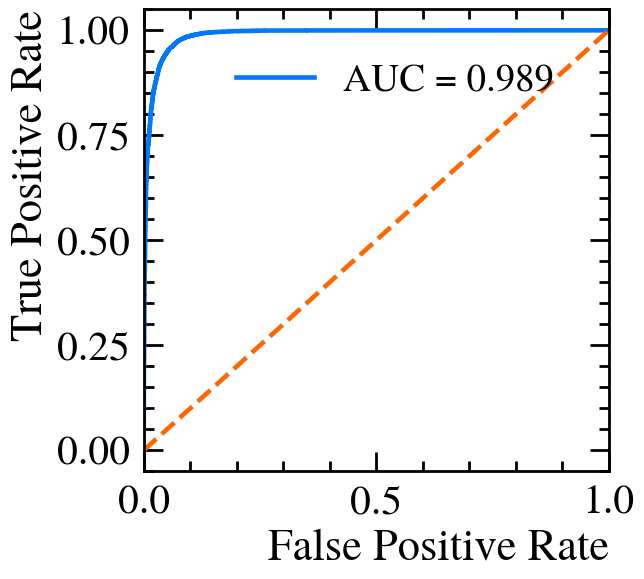

In [15]:
y_pred = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.savefig("D:/b_meson_analysis/charm_baryon_analysis/plots/charm_tagger_roc.png")
plt.show()

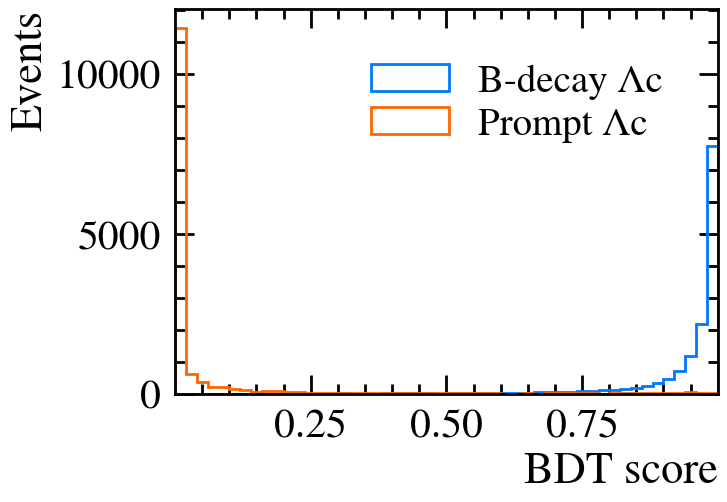

In [16]:
plt.figure(figsize=(7,5))

plt.hist(y_pred[y_test==1], bins=50, histtype="step",
         label="B-decay Λc")

plt.hist(y_pred[y_test==0], bins=50, histtype="step",
         label="Prompt Λc")

plt.xlabel("BDT score")
plt.ylabel("Events")
plt.legend()

plt.savefig("D:/b_meson_analysis/charm_baryon_analysis/plots/charm_tagger_response.png")
plt.show()

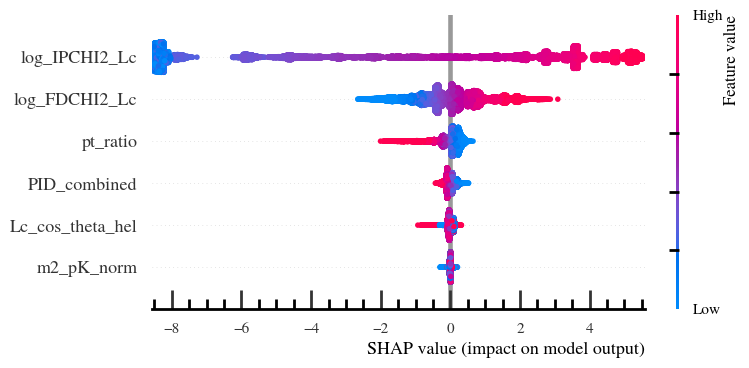

In [17]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [18]:
thresholds = np.linspace(0.1, 0.9, 50)

eff_tag = []
rej_prompt = []
fom = []

for t in thresholds:
    pred = y_pred > t

    sig_eff = np.mean(pred[y_test==1])
    bkg_rej = 1 - np.mean(pred[y_test==0])

    eff_tag.append(sig_eff)
    rej_prompt.append(bkg_rej)
    fom.append(sig_eff * bkg_rej)

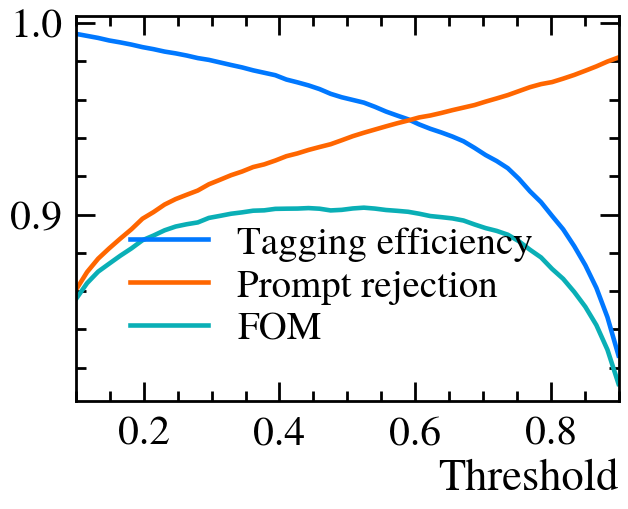

In [19]:
plt.figure(figsize=(7,5))

plt.plot(thresholds, eff_tag, label="Tagging efficiency")
plt.plot(thresholds, rej_prompt, label="Prompt rejection")
plt.plot(thresholds, fom, label="FOM")

plt.xlabel("Threshold")
plt.legend()

plt.savefig("D:/b_meson_analysis/charm_baryon_analysis/plots/charm_tagger_performance.png")
plt.show()

In [20]:
best_idx = np.argmax(fom)

print("Optimal threshold:", thresholds[best_idx])
print("Tagging efficiency:", eff_tag[best_idx])
print("Prompt rejection:", rej_prompt[best_idx])

Optimal threshold: 0.5244897959183674
Tagging efficiency: 0.9584666666666667
Prompt rejection: 0.9427333333333333


In [21]:
N_B = 1e9
BF = 0.06
eps_reco = 0.10
eps_tag = eff_tag[best_idx]

N_new = N_B * BF * eps_reco * eps_tag

gain = N_new / N_B

print(f"New tagging contribution: {gain*100:.2f}%")
print(f"Relative improvement over FEI (~0.3%): {gain/0.003:.2f}x")

New tagging contribution: 0.58%
Relative improvement over FEI (~0.3%): 1.92x
